In [2]:
import os
import numpy as np
import pandas as pd
import lightkurve as lk
import batman
from tqdm import tqdm
import glob
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.model_selection import train_test_split
import sys
import warnings

In [3]:
# Suppress lightkurve warnings about missing flux_err and normalization
warnings.filterwarnings("ignore", module="lightkurve")
warnings.filterwarnings("ignore", message="The light curve contains NaN values")

# Configuration
DATA_DIR = "pipeline_output_final_data"
BAYESIAN_OUTPUT = os.path.join(DATA_DIR, "bayesian_unfolded")
METADATA_FILE = 'q1_q8_koi_2025.02.03_04.12.15.csv' # uploaded file
HEADER_ROW = 53 # Based on the file structure
ML_BATCH_SIZE = 1000 
CNN_GLOBAL_LENGTH = 2001
CNN_LOCAL_LENGTH = 201
LOCAL_WINDOW_DUR_MULTIPLIER = 4.0
OUTLIER_SIGMA = 5.0 
MAX_WORKERS = 8 

# Subsampling for fast development (Set to 0 to run full dataset)
SUBSAMPLE_SIZE = 0 # Set to 0 to process all 3865 available targets

os.makedirs(BAYESIAN_OUTPUT, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# METADATA CREATION (FIXED)

def create_master_metadata(file_path):
    """
    Reads the KOI catalog, creates binary labels, ensures data integrity, 
    and shuffles the final list to mix positive and negative samples.
    """
    print("Creating Master Metadata")
    try:
        # Load data using the known header row
        df = pd.read_csv(file_path, header=HEADER_ROW, 
                         usecols=['kepid', 'koi_period', 'koi_time0bk', 'koi_duration', 'koi_disposition'])
    except FileNotFoundError:
        print(f"Error: KOI file not found at {file_path}. Cannot proceed.")
        return pd.DataFrame()

    # Create Binary Label
    df['label'] = df['koi_disposition'].apply(
        lambda x: 1 if x in ['CONFIRMED', 'CANDIDATE'] else 0
    )
    
    # Rename and clean up
    df.rename(columns={'kepid': 'kepid', 'koi_period': 'period', 
                       'koi_time0bk': 't0', 'koi_duration': 'duration'}, inplace=True)
    
    # Ensure KIC ID is clean and drop rows missing essential parameters
    df.dropna(subset=['kepid', 'period', 't0', 'duration'], inplace=True)
    df['kepid'] = df['kepid'].astype(int)
    
    # Remove duplicates (multiple KOIs for the same KIC, but usually for multi-planet systems)
    # Keeping all rows is intentional for multi-planet systems, but we ensure unique KIC IDs for the file system resume check
    df = df.drop_duplicates(subset=['kepid', 'period', 't0'])

    print(f"Master metadata created with {len(df)} unique TCEs (Transiting Candidate Events).")
    print(f"Initial Class Balance: {df['label'].value_counts().to_dict()}")

    # Apply subsampling if configured
    if SUBSAMPLE_SIZE > 0 and len(df) > SUBSAMPLE_SIZE:
        print(f"Applying subsampling to {SUBSAMPLE_SIZE} samples for fast processing.")
        
        # Ensure we don't request more than available
        tp_count = len(df[df['label'] == 1])
        tn_count = len(df[df['label'] == 0])
        
        target_tp = min(SUBSAMPLE_SIZE // 2, tp_count)
        target_tn = min(SUBSAMPLE_SIZE // 2, tn_count)

        tp_subset = df[df['label'] == 1].sample(target_tp, random_state=42)
        tn_subset = df[df['label'] == 0].sample(target_tn, random_state=42)
        
        # FIX: Shuffle the combined dataset so labels are mixed!
        df = pd.concat([tp_subset, tn_subset]).sample(frac=1, random_state=42).reset_index(drop=True)
        
        print(f"Final sampled size: {len(df)}. Labels are now correctly shuffled.")
        print(f"Final sampled Class Balance: {df['label'].value_counts().to_dict()}")

    return df.drop(columns=['koi_disposition'])

# CORE PREPROCESSING (PARALLEL WORKER FUNCTION)

def get_and_clean_lightcurve(kic_id, tce_period, tce_t0, tce_duration):
    """
    Downloads, stitches, detrends, and normalizes a single light curve using lightkurve best practices.
    """
    kic_id_str = str(int(kic_id))
    
    # 1. Download and Stitch (using lightkurve)
    search_result = lk.search_lightcurve(f'KIC {kic_id_str}', mission='Kepler', author='Kepler')
    
    if not search_result:
        return None 

    lc_collection = search_result.download_all()
    
    if lc_collection is None:
        return None

    # Stitching and removing NaNs
    stitched_lc = lc_collection.stitch().remove_nans()
    
    # 2. Detrending (Flattening with Transit Mask)
    # Use the planet parameters to mask the transits during detrending, 
    # preserving the transit shape while removing stellar noise.
    if pd.notna(tce_period) and pd.notna(tce_t0):
        # Create a transit mask (masking out the area around the transit)
        folded_lc = stitched_lc.fold(tce_period, t0=tce_t0)
        in_transit_phase = (tce_duration / 24) / tce_period 
        transit_mask = np.abs(folded_lc.phase.value) < in_transit_phase * 0.5
        mask_array = np.asarray(transit_mask.data)
        
        # Flatten the light curve, ignoring the masked transit area
        flat_lc = stitched_lc.flatten(mask=~mask_array, sigma=OUTLIER_SIGMA)
    else:
        # If parameters are missing (should not happen in this fixed pipeline), just flatten.
        flat_lc = stitched_lc.flatten(sigma=OUTLIER_SIGMA)
    
    # Final Normalization
    norm_flux = flat_lc.flux.value
    flux_err = flat_lc.flux_err.value
    
    norm_flux = (norm_flux - np.median(norm_flux)) # Median 0
    
    if np.min(norm_flux) < 0:
        scale_factor = 1.0 / np.abs(np.min(norm_flux))
        norm_flux = norm_flux * scale_factor
        flux_err = flux_err * scale_factor if flux_err is not None else None
    
    # Return time, flux, error, and metadata for further processing
    ml_sample = {
        'kepid': kic_id,
        'time': flat_lc.time.value,
        'flux': norm_flux,
        'flux_err': flux_err,
        'period': tce_period,
        't0': tce_t0,
        'duration': tce_duration,
        'label': 0, # Placeholder
        'is_synthetic': 0
    }
    
    return ml_sample

def process_single_kic_worker(row):
    """The function executed by each thread for a single TCE."""
    kic_id = row['kepid']
    
    try:
        # Use TCE specific parameters
        ml_sample = get_and_clean_lightcurve(
            kic_id, row['period'], row['t0'], row['duration']
        )
        
        if ml_sample is None:
            return None, None
        
        # Update label from master metadata
        ml_sample['label'] = row['label']
        
        # Output for Bayesian Model (Unfolded CSV)
        # We must save this file even for multi-planet systems as it represents the star's light curve
        unfolded_data = pd.DataFrame({
            'time': ml_sample['time'],
            'flux': ml_sample['flux'],
            'flux_err': ml_sample['flux_err']
        })
        filename_b = f'kic_{kic_id}_unfolded.csv'
        filepath_b = os.path.join(BAYESIAN_OUTPUT, filename_b)
        unfolded_data.to_csv(filepath_b, index=False)
        
        # Return the processed sample for subsequent CNN stages
        return ml_sample, filepath_b
        
    except Exception as e:
        # print(f"Error processing KIC {kic_id}: {e}")
        return None, None 

# AUGMENTATION (Synthetic Injection Logic)

def create_synthetic_transit(time, period, t0, duration, rp_rs, u=[0.1, 0.3]):
    """Generates a synthetic transit light curve using batman."""
    params = batman.TransitParams() 
    params.t0 = t0
    params.per = period
    params.rp = rp_rs
    params.a = 15.0 
    params.inc = 89.9
    params.ecc = 0.
    params.w = 90.
    params.u = u 
    params.limb_dark = "quadratic"
    m = batman.TransitModel(params, time)
    return m.light_curve(params)

def inject_and_normalize(time, flux, flux_err, syn_params):
    """Injects synthetic signal and re-normalizes."""
    syn_flux_model = create_synthetic_transit(
        time, syn_params['period'], syn_params['t0'], syn_params['duration'] / 24, syn_params['rp_rs']
    )
    dip = syn_flux_model - 1.0 
    injected_flux = flux + dip 
    
    # Re-normalize injected flux
    norm_flux = injected_flux
    norm_flux = (norm_flux - np.median(norm_flux))
    
    if np.min(norm_flux) < 0:
        scale_factor = 1.0 / np.abs(np.min(norm_flux))
        norm_flux = norm_flux * scale_factor
        flux_err = flux_err * scale_factor if flux_err is not None else None
        
    return norm_flux, flux_err


# CNN DUAL-VIEW CREATION & SAVING

def create_cnn_dual_view(time, flux, period, t0, duration):
    """
    Creates Global and Local views. 
    Fixes:
    1. Uses 'epoch_time' instead of 't0' to silence warnings.
    2. Folds Local View on the ACTUAL period to stack transits (fixes empty views).
    3. Checks for empty views to prevent IndexError crashes.
    4. Removes 'method' argument from bin() to fix TypeError.
    """
    if len(time) < 100: 
        return np.full(CNN_GLOBAL_LENGTH, np.nan), np.full(CNN_LOCAL_LENGTH, np.nan)
        
    lc = lk.LightCurve(time=time, flux=flux)
    
    # GLOBAL VIEW (Full Orbit)
    try:
        # Fold on actual period to stack all data
        folded_global = lc.fold(period=period, epoch_time=t0)
        
        # Bin to fixed length
        binned_global = folded_global.bin(bins=CNN_GLOBAL_LENGTH) 
        flux_global = binned_global.flux.value
    except Exception:
        return np.full(CNN_GLOBAL_LENGTH, np.nan), np.full(CNN_LOCAL_LENGTH, np.nan)
    
    
    # LOCAL VIEW (Zoomed on Transit)
    try:
        # Define the window width in PHASE units
        # Window = Multiplier * Duration
        # Phase = Time / Period
        # So: Phase_Window = (Multiplier * (Duration / 24)) / Period
        duration_days = duration / 24.0
        local_window_days = LOCAL_WINDOW_DUR_MULTIPLIER * duration_days
        local_phase_width = local_window_days / period
        
        # Reuse the folded object from above (it's already folded on the correct period/t0)
        # Mask to keep only the data inside the zoom window
        local_mask = np.abs(folded_global.phase.value) < (local_phase_width / 2)
        
        # Extract the zoomed data
        flux_local_raw = folded_global.flux.value[local_mask]
        phase_local_raw = folded_global.phase.value[local_mask]
        
        if len(flux_local_raw) == 0:
            # If empty (e.g. really short period or bad data), return NaNs
            return np.full(CNN_GLOBAL_LENGTH, np.nan), np.full(CNN_LOCAL_LENGTH, np.nan)

        # Create a temporary LightCurve for binning the local view
        lc_local = lk.LightCurve(time=phase_local_raw, flux=flux_local_raw)
        
        # Bin to fixed length (201 points)
        binned_local = lc_local.bin(bins=CNN_LOCAL_LENGTH)
        flux_local = binned_local.flux.value
        
    except Exception:
         return np.full(CNN_GLOBAL_LENGTH, np.nan), np.full(CNN_LOCAL_LENGTH, np.nan)

    # Ensure exact output size (sometimes binning is off by 1)
    if len(flux_global) != CNN_GLOBAL_LENGTH:
        flux_global = np.pad(flux_global, (0, max(0, CNN_GLOBAL_LENGTH - len(flux_global))), mode='edge')[:CNN_GLOBAL_LENGTH]
        
    if len(flux_local) != CNN_LOCAL_LENGTH:
        flux_local = np.pad(flux_local, (0, max(0, CNN_LOCAL_LENGTH - len(flux_local))), mode='edge')[:CNN_LOCAL_LENGTH]
    
    return flux_global, flux_local

def save_cnn_batches(ml_samples):
    """Batches and saves the dual-view data to compressed NPZ files."""
    print("\n--- Stage 3A.3: Saving CNN Batches to NPZ ---")
    all_metadata = []
    
    # Randomly split into Train/Val/Test data
    train_val_test_split_indices = {}
    indices = np.arange(len(ml_samples))
    train_indices, test_val_indices = train_test_split(indices, test_size=0.2, random_state=42)
    val_indices, test_indices = train_test_split(test_val_indices, test_size=0.5, random_state=42)
    
    for i in train_indices: train_val_test_split_indices[i] = 'train'
    for i in val_indices: train_val_test_split_indices[i] = 'val'
    for i in test_indices: train_val_test_split_indices[i] = 'test'
    
    
    for i in tqdm(range(0, len(ml_samples), ML_BATCH_SIZE), desc="Saving ML batches"):
        batch = ml_samples[i:i + ML_BATCH_SIZE]
        batch_num = i // ML_BATCH_SIZE + 1
        filename = f'batch_{batch_num}.npz'
        filepath = os.path.join(DATA_DIR, filename)

        batch_flux_global = np.stack([s['flux_global'] for s in batch]).astype(np.float32)
        batch_flux_local = np.stack([s['flux_local'] for s in batch]).astype(np.float32)
        
        np.savez_compressed(
            filepath,
            flux_global=batch_flux_global,
            flux_local=batch_flux_local,
            label=np.array([s['label'] for s in batch], dtype=np.float32)
        )
        
        # Create metadata entries
        for idx, s in enumerate(batch):
            global_index = i + idx
            all_metadata.append({
                'kepid': s['kepid'],
                'label': s['label'],
                'period': s['period'],
                'filename': filename,
                'index_in_batch': idx,
                'is_synthetic': s['is_synthetic'],
                'split': train_val_test_split_indices.get(global_index, 'unknown')
            })
            
    final_metadata_df = pd.DataFrame(all_metadata)
    final_metadata_df.to_csv(os.path.join(DATA_DIR, "final_metadata.csv"), index=False)
    
    print(f"Final ML dataset of size {len(final_metadata_df)} saved successfully (NPZ + Metadata).")

# RUN THE ENTIRE PIPELINE

def run_pipeline():
    # METADATA
    master_df = create_master_metadata(METADATA_FILE)
    if master_df.empty: return

    # We must check against unique KIC IDs in the Bayesian folder 
    # since that file is the source data for both models.
    existing_files = glob.glob(os.path.join(BAYESIAN_OUTPUT, 'kic_*.csv'))
    
    # We use the unique KIC ID as the identifier for a processed star
    processed_kic_ids = {
        int(float(os.path.basename(f).split('_')[1]))
        for f in existing_files
    }
    
    kics_to_process = master_df[~master_df['kepid'].isin(processed_kic_ids)]
    kics_already_done = master_df[master_df['kepid'].isin(processed_kic_ids)]
    
    print(f"\nResume Check")
    print(f"Skipping {len(kics_already_done)} KIC IDs already processed.")
    print(f"Remaining {len(kics_to_process)} TCEs to process.")
    
    
    # PROCESS NEW KICs (DOWNLOAD/CLEAN/SAVE)
    newly_processed_samples = []
    
    if not kics_to_process.empty:
        print(f"\nParallel Core Processing with {MAX_WORKERS} workers")
        
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            future_to_kic = {
                executor.submit(process_single_kic_worker, row): (row['kepid'], row['period'])
                for _, row in kics_to_process.iterrows()
            }
            
            for future in tqdm(as_completed(future_to_kic), total=len(kics_to_process), desc="Processing NEW TCEs"):
                result = future.result()
                if result[0] is not None:
                    newly_processed_samples.append(result[0])
                    
        print(f"Processing of NEW TCEs complete. Processed {len(newly_processed_samples)} samples.")


    # LOAD EXISTING KICs FROM DISK
        
    print(f"\nLoading {len(kics_already_done)} existing samples from disk")
    existing_samples_from_disk = []
    
    # Iterate over ALL TCEs that were previously processed, regardless of KIC ID duplication
    for index, row in tqdm(kics_already_done.iterrows(), total=len(kics_already_done), desc="Loading from disk"):
        kic_id = row['kepid']
        
        # Read the single unfolded CSV file (which may contain data relevant to multiple TCEs)
        filepath = os.path.join(BAYESIAN_OUTPUT, f'kic_{kic_id}_unfolded.csv')
        
        try:
            unfolded_data = pd.read_csv(filepath)
            
            sample = {
                'kepid': kic_id,
                'time': unfolded_data['time'].values,
                'flux': unfolded_data['flux'].values,
                'flux_err': unfolded_data['flux_err'].values if 'flux_err' in unfolded_data else None,
                'period': row['period'], 't0': row['t0'], 'duration': row['duration'],
                'label': row['label'], 'is_synthetic': 0
            }
            existing_samples_from_disk.append(sample)
        except Exception:
            pass
            
    # Combine ALL samples: newly processed + existing 
    ml_samples = newly_processed_samples + existing_samples_from_disk
    
    if not ml_samples:
        print("Error: No light curves were successfully processed or loaded. Cannot proceed.")
        sys.exit()

    # AUGMENTATION
    
    tn_samples = [s for s in ml_samples if s['label'] == 0 and s['time'].size > 0]
    num_real_tp = len([s for s in ml_samples if s['label'] == 1])
    
    # Target synthetic samples to match/exceed the number of real TPs
    num_syn_to_inject = max(100, num_real_tp * 2) 
    
    print(f"\nData Augmentation (Targeting {num_syn_to_inject} synthetic samples)")
    synthetic_samples = []
    
    if tn_samples:
        for i in tqdm(range(num_syn_to_inject), desc="Injecting synthetic data"):
            # Cycle through TN samples to use as hosts
            host = tn_samples[i % len(tn_samples)] 
            
            # Randomly generated planet parameters for augmentation
            syn_params = {
                'period': np.random.uniform(5, 50), 't0': np.random.uniform(host['time'].min(), host['time'].min() + 50),
                'duration': np.random.uniform(1.0, 5.0), 'rp_rs': np.random.uniform(0.005, 0.03) # Small planets
            }
            
            injected_flux, injected_err = inject_and_normalize(
                host['time'], host['flux'], host['flux_err'], syn_params
            )

            synthetic_samples.append({
                # Keep host metadata but update planet parameters and label
                'kepid': host['kepid'], 'time': host['time'], 'flux': injected_flux, 'flux_err': injected_err,
                'period': syn_params['period'], 't0': syn_params['t0'], 'duration': syn_params['duration'],
                'label': 1, 'is_synthetic': 1
            })
    else:
        print("Warning: No True Negative samples found for synthetic data injection. Skipping augmentation.")
        
    all_ml_samples = ml_samples + synthetic_samples
    print(f"Total samples (Real + Synthetic): {len(all_ml_samples)}")
    
    # CNN DUAL-VIEW CREATION & SAVING
    
    final_ml_samples = []
    print("\n--- Stage 3A: Creating CNN Dual Views (Sequential) ---")
    
    for s in tqdm(all_ml_samples, desc="Creating Dual Views"):
        flux_global, flux_local = create_cnn_dual_view(s['time'], s['flux'], s['period'], s['t0'], s['duration'])
        
        # Check for NaN (which happens if the folding/binning failed)
        if not np.all(np.isnan(flux_global)):
            final_ml_samples.append({**s, 'flux_global': flux_global, 'flux_local': flux_local})
            
    # Final Output
    save_cnn_batches(final_ml_samples)
    
    print("\nPipeline finished. Data ready for model training in the 'pipeline_output_final_data' directory.")

In [ ]:
if __name__ == '__main__':
    run_pipeline()

Creating Master Metadata
Master metadata created with 3865 unique TCEs (Transiting Candidate Events).
Initial Class Balance: {1: 2585, 0: 1280}

Resume Check
Skipping 982 KIC IDs already processed.
Remaining 2883 TCEs to process.

Parallel Core Processing with 8 workers


Processing NEW TCEs:   0%|          | 1/2883 [00:06<5:00:38,  6.26s/it]

In [4]:
# EMERGENCY EXIT: SKIP DOWNLOADS AND USE ONLY SAVED DATA

# Load Metadata
master_df = create_master_metadata(METADATA_FILE)

# Find ONLY what is on disk
existing_files = glob.glob(os.path.join(BAYESIAN_OUTPUT, 'kic_*.csv'))
processed_kic_ids = {
    int(float(os.path.basename(f).split('_')[1])) 
    for f in existing_files
}

# Filter metadata to ONLY keep what we already have
# This forces the pipeline to ignore the ones that failed/are missing
kics_already_done = master_df[master_df['kepid'].isin(processed_kic_ids)]
print(f"\nFound {len(kics_already_done)} successful downloads on disk.")
print("Skipping all other targets to finalize pipeline immediately.")

# 3. Load Data
ml_samples = []
for index, row in tqdm(kics_already_done.iterrows(), total=len(kics_already_done), desc="Loading from disk"):
    kic_id = row['kepid']
    filepath = os.path.join(BAYESIAN_OUTPUT, f'kic_{kic_id}_unfolded.csv')
    try:
        unfolded_data = pd.read_csv(filepath)
        sample = {
            'kepid': kic_id,
            'time': unfolded_data['time'].values,
            'flux': unfolded_data['flux'].values,
            'flux_err': unfolded_data['flux_err'].values if 'flux_err' in unfolded_data else None,
            'period': row['period'], 't0': row['t0'], 'duration': row['duration'],
            'label': row['label'], 'is_synthetic': 0
        }
        ml_samples.append(sample)
    except Exception:
        pass

# Augment and Save
tn_samples = [s for s in ml_samples if s['label'] == 0 and s['time'].size > 0]
num_real_tp = len([s for s in ml_samples if s['label'] == 1])
num_syn_to_inject = max(100, num_real_tp * 2) 

print(f"\nAugmenting Data (Injecting {num_syn_to_inject} synthetic samples)")
synthetic_samples = []
if tn_samples:
    for i in tqdm(range(num_syn_to_inject), desc="Injecting synthetic data"):
        host = tn_samples[i % len(tn_samples)] 
        syn_params = {
            'period': np.random.uniform(5, 50), 't0': np.random.uniform(host['time'].min(), host['time'].min() + 50),
            'duration': np.random.uniform(1.0, 5.0), 'rp_rs': np.random.uniform(0.005, 0.03) 
        }
        injected_flux, injected_err = inject_and_normalize(
            host['time'], host['flux'], host['flux_err'], syn_params
        )
        synthetic_samples.append({
            'kepid': host['kepid'], 'time': host['time'], 'flux': injected_flux, 'flux_err': injected_err,
            'period': syn_params['period'], 't0': syn_params['t0'], 'duration': syn_params['duration'],
            'label': 1, 'is_synthetic': 1
        })

all_ml_samples = ml_samples + synthetic_samples
print(f"Total samples for CNN: {len(all_ml_samples)}")

# 5. Create CNN Views
final_ml_samples = []
print("\nCreating CNN Dual Views")
for s in tqdm(all_ml_samples):
    flux_global, flux_local = create_cnn_dual_view(s['time'], s['flux'], s['period'], s['t0'], s['duration'])
    
    # Only save if we got valid data (check the first element)
    if not np.isnan(flux_global[0]):
        final_ml_samples.append({**s, 'flux_global': flux_global, 'flux_local': flux_local})

print(f"Successfully created views for {len(final_ml_samples)} samples.")
save_cnn_batches(final_ml_samples)

Creating Master Metadata
Master metadata created with 3865 unique TCEs (Transiting Candidate Events).
Initial Class Balance: {1: 2585, 0: 1280}

Found 982 successful downloads on disk.
Skipping all other targets to finalize pipeline immediately.


Loading from disk: 100%|██████████| 982/982 [00:54<00:00, 18.14it/s]



Augmenting Data (Injecting 666 synthetic samples)


Injecting synthetic data: 100%|██████████| 666/666 [00:14<00:00, 45.35it/s]


Total samples for CNN: 1184

Creating CNN Dual Views


C:\Users\ztsch\anaconda3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
C:\Users\ztsch\anaconda3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
C:\Users\ztsch\anaconda3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "utctai" yielded 201 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
C:\Users\ztsch\anaconda3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 201 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
C:\Users\ztsch\anaconda3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "utctai" yielded 201 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', Er

KeyboardInterrupt: 

In [5]:
# Load the metadata to know which star is which
metadata = pd.read_csv('pipeline_output_final_data/final_metadata.csv')

# Load a batch of data (e.g., batch_1.npz)
data = np.load('pipeline_output_final_data/batch_1.npz')

# Access the arrays
global_views = data['flux_global']  # Shape: (1000, 2001)
local_views  = data['flux_local']   # Shape: (1000, 201)
labels       = data['label']        # Shape: (1000,)

# Get the Global View for the first star in this batch
first_star_flux = global_views[0]
print(f"Loaded star with Label: {labels[0]}")

Loaded star with Label: 1.0


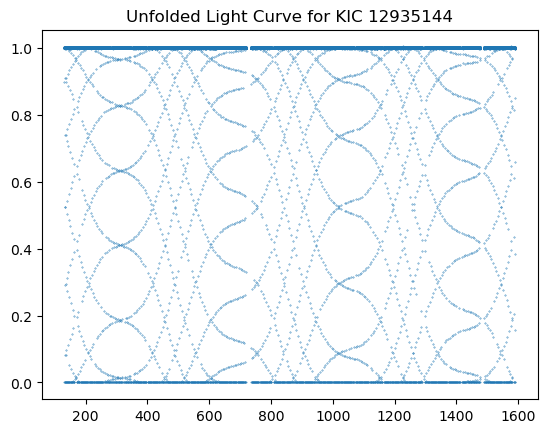

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Select a star
kic_id = 12935144
file_path = f'pipeline_output_final_data/bayesian_unfolded/kic_{kic_id}_unfolded.csv'

# Load the data
df = pd.read_csv(file_path)

# Use time and flux
time = df['time']
flux = df['flux']

# 4. Plot
plt.scatter(time, flux, s=0.1)
plt.title(f"Unfolded Light Curve for KIC {kic_id}")
plt.show()

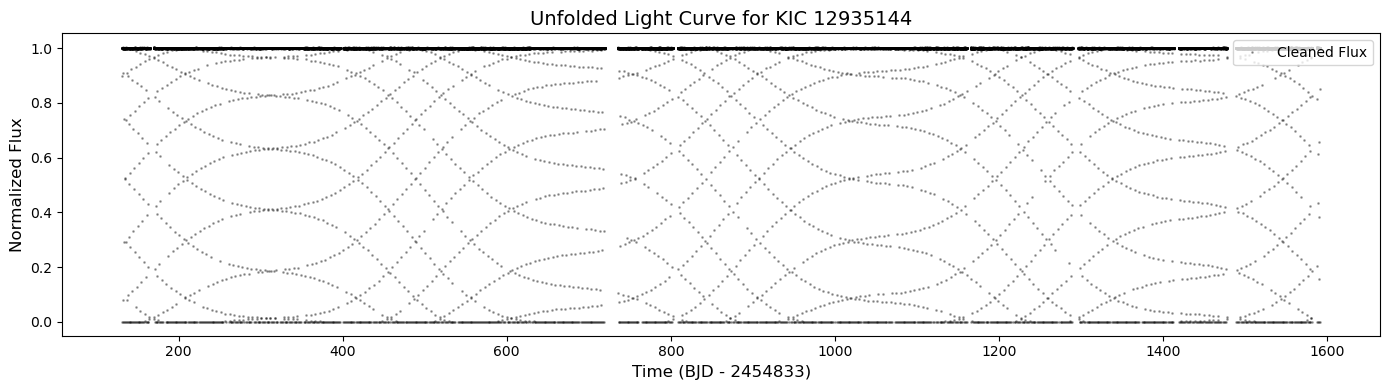

✅ Successfully plotted kic_12935144_unfolded.csv
Total data points: 64725


In [8]:
import matplotlib.pyplot as plt

output_dir = "pipeline_output_final_data/bayesian_unfolded"

kic_id = 12935144
filename = f"kic_{kic_id}_unfolded.csv"
filepath = os.path.join(output_dir, filename)

try:
    # Load the data
    df = pd.read_csv(filepath)

    # Plot
    plt.figure(figsize=(14, 4))
    
    # Plot dots with low alpha to see density
    plt.plot(df['time'], df['flux'], 'k.', markersize=2, alpha=0.3, label='Cleaned Flux')
    
    plt.title(f"Unfolded Light Curve for KIC {kic_id}", fontsize=14)
    plt.xlabel("Time (BJD - 2454833)", fontsize=12)
    plt.ylabel("Normalized Flux", fontsize=12)
    plt.legend(loc='upper right')
    plt.show()
    
    print(f"Successfully plotted {filename}")
    print(f"Total data points: {len(df)}")
    
except FileNotFoundError:
    print(f"Could not find file: {filepath}")
    print("Check your directory name and KIC ID.")

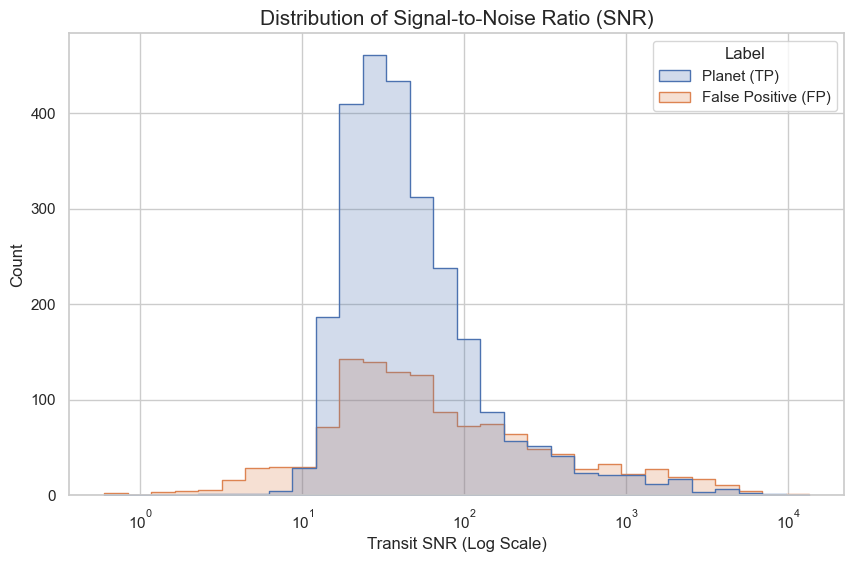

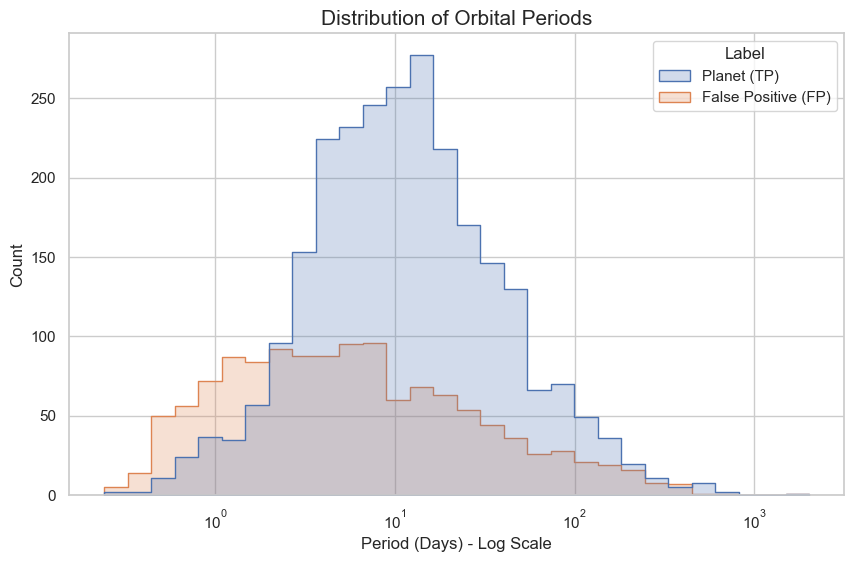

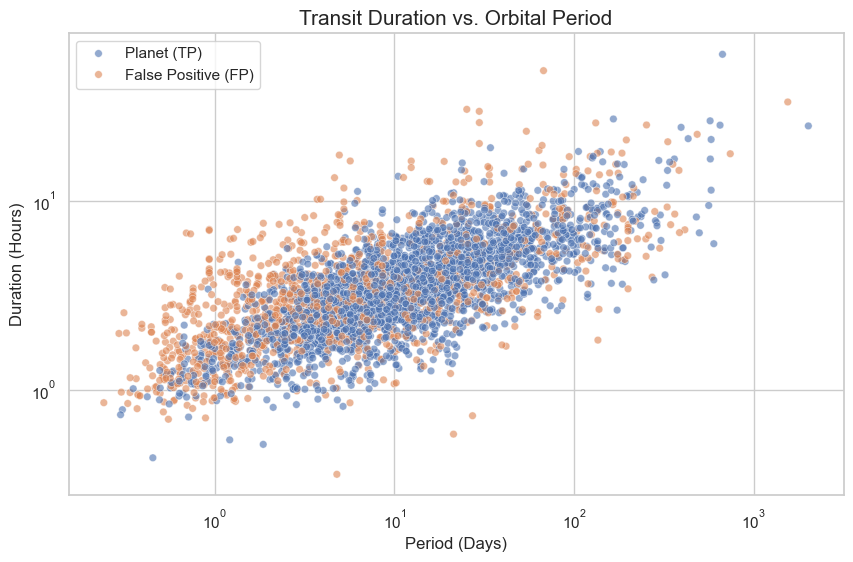

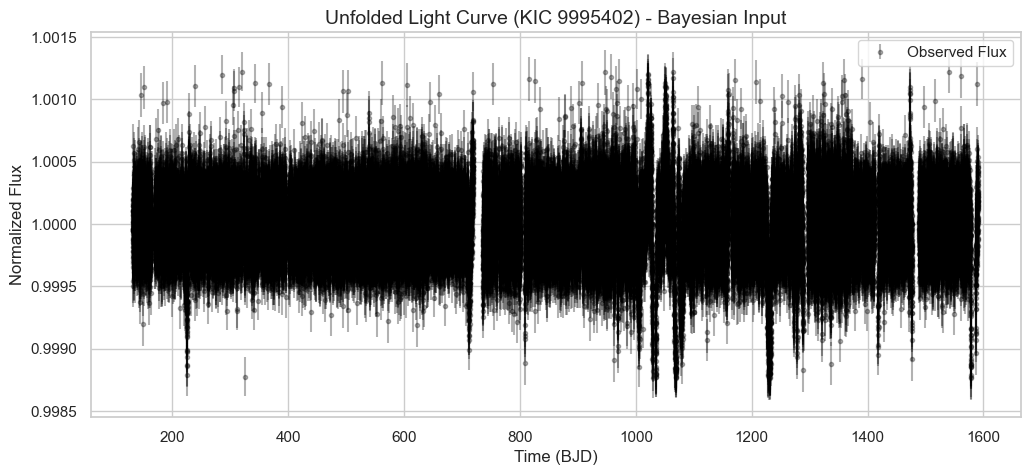

Plots created successfully.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the metadata
file_path = 'q1_q8_koi_2025.02.03_04.12.15.csv'
# Using header=53 as determined in previous turns
df = pd.read_csv(file_path, header=53)

# Create Labels
df['Label'] = df['koi_disposition'].apply(lambda x: 'Planet (TP)' if x in ['CONFIRMED', 'CANDIDATE'] else 'False Positive (FP)')

# Filter out extreme outliers for better visualization if necessary, but log scales usually handle it.
# Let's clean up key columns just in case
df = df.dropna(subset=['koi_model_snr', 'koi_period', 'koi_duration'])

# Set style
sns.set(style="whitegrid")

# Plot 1: Signal-to-Noise Ratio Distribution (Log Scale)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='koi_model_snr', hue='Label', log_scale=True, element="step", common_norm=False, bins=30)
plt.title('Distribution of Signal-to-Noise Ratio (SNR)', fontsize=15)
plt.xlabel('Transit SNR (Log Scale)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.savefig('dist_snr.png')

# Plot 2: Distribution of Orbital Periods (Log Scale)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='koi_period', hue='Label', log_scale=True, element="step", common_norm=False, bins=30)
plt.title('Distribution of Orbital Periods', fontsize=15)
plt.xlabel('Period (Days) - Log Scale', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.savefig('dist_period.png')

# Plot 3: Transit Duration vs Orbital Period
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='koi_period', y='koi_duration', hue='Label', alpha=0.6, s=30)
plt.xscale('log')
plt.yscale('log')
plt.title('Transit Duration vs. Orbital Period', fontsize=15)
plt.xlabel('Period (Days)', fontsize=12)
plt.ylabel('Duration (Hours)', fontsize=12)
plt.legend(loc='upper left')
plt.savefig('scatter_period_duration.png')

# Plot 4: Plots one random unfolded light curve for the Bayesian team.
files = glob.glob(f"{DATA_DIR}/bayesian_unfolded/*.csv")
if not files:
    print("No unfolded CSVs found.")
    
filename = files[-1]
kic = os.path.basename(filename).split('_')[1]
    
df = pd.read_csv(filename)
plt.figure(figsize=(12, 5))
plt.errorbar(df['time'], df['flux'], yerr=df['flux_err'], fmt='.', color='black', alpha=0.3, label='Observed Flux')
plt.title(f"Unfolded Light Curve (KIC {kic}) - Bayesian Input", fontsize=14)
plt.xlabel("Time (BJD)", fontsize=12)
plt.ylabel("Normalized Flux", fontsize=12)
plt.legend()
plt.savefig("bayesian_example.png")
plt.show()

print("Plots created successfully.")

In [16]:
import shutil
import os

# Define the folder to zip and the output name
source_folder = "pipeline_output_final_data"
output_filename = "kepler_dataset_v1"

print(f"Zipping '{source_folder}'... this may take a minute.")

# Create the zip file
shutil.make_archive(output_filename, 'zip', source_folder)

print(f"Success! File created: {output_filename}.zip")
print(f"File size: {os.path.getsize(output_filename + '.zip') / (1024*1024):.2f} MB")

Zipping 'pipeline_output_final_data'... this may take a minute.
Success! File created: kepler_dataset_v1.zip
File size: 1420.79 MB
